# **Training models**

### **Library imports and creation of the baseline**

In this section, we define the criteria for determining user satisfaction. Using the rating variable, we establish that a film is classified as 'liked' by the community if its score is 3.5 or higher; otherwise, it is classified as negative or neutral. Following this target definition, we separate the data into input features and output labels to prepare them for the training stage.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

print("Loading data")
df = pd.read_pickle("data_processed.pkl")
df['text_content'] = df['text_content'].fillna("")

# We define if a film was liked by getting films which rating was above 3.5
df['is_liked'] = (df['rating'] >= 3.5).astype(int)

# We save columns into global variables that we will use during training.
X = df['text_content']
y = df['is_liked']

print(f"Size of the Dataset: {len(df)}")
print(f"Distribution of reviews - Positives (1): {y.sum()} | Negatives (0): {len(df) - y.sum()}")

Loading data
Size of the Dataset: 284234
Distribution of reviews - Positives (1): 212857 | Negatives (0): 71377


### **Text Model training**

We separate the tests and training set for the text data

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"• Training set (X_train): {X_train.shape[0]}")
print(f"• Test set (X_test): {X_test.shape[0]} ")

• Training set (X_train): 227387
• Test set (X_test): 56847 


#### **Bag of words and training**

We apply Bag of Words (BoW) vectorization via CountVectorizer to transform our raw text data into numerical features, keeping a maximum of 5,000 terms. We then fit two baseline classification models on this representation: Naive Bayes and Logistic Regression (configured with 1,000 iterations to ensure convergence). Finally, both models generate predictions on the test set to establish our baseline performance for textual data.

In [17]:
# Vectorization of the dataset
print("Vectorizing with Bag of Words (BoW)...")
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# 1. Naive Bayes with BoW
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
preds_nb_bow = nb_bow.predict(X_test_bow)

# 2. Logistic regression with BoW
lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(X_train_bow, y_train)
preds_lr_bow = lr_bow.predict(X_test_bow)

print("Models trained with Bag of Words.")

Vectorizing with Bag of Words (BoW)...
Models trained with Bag of Words.


#### **Tfid vectorizer and training**

We upgrade our feature extraction using TfidfVectorizer with a 5,000-word limit. Unlike Bag of Words, TF-IDF penalizes generic words and rewards highly specific, meaningful terms. We then fit Naive Bayes and Logistic Regression onto this new feature space and generate predictions on the test set. This allows us to directly compare the efficacy of frequency-based vs. importance-based text vectorization methods.

In [18]:
print("Vectorizing with TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# 1. Naive Bayes with TF-IDF
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
preds_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

# 2. Logistic regression with TF-IDF
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)
preds_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

print("Models trained with TF-IDF.")

Vectorizing with TF-IDF...
Models trained with TF-IDF.


### **Learning curve for text models**

This section generates a $2 \times 2$ grid of learning curves to visually monitor and analyze convergence patterns across all textual classification pipelines.

Computing Learning Curve for BoW + Naive Bayes...
Computing Learning Curve for BoW + Logistic Regression...
Computing Learning Curve for TF-IDF + Naive Bayes...
Computing Learning Curve for TF-IDF + Logistic Regression...


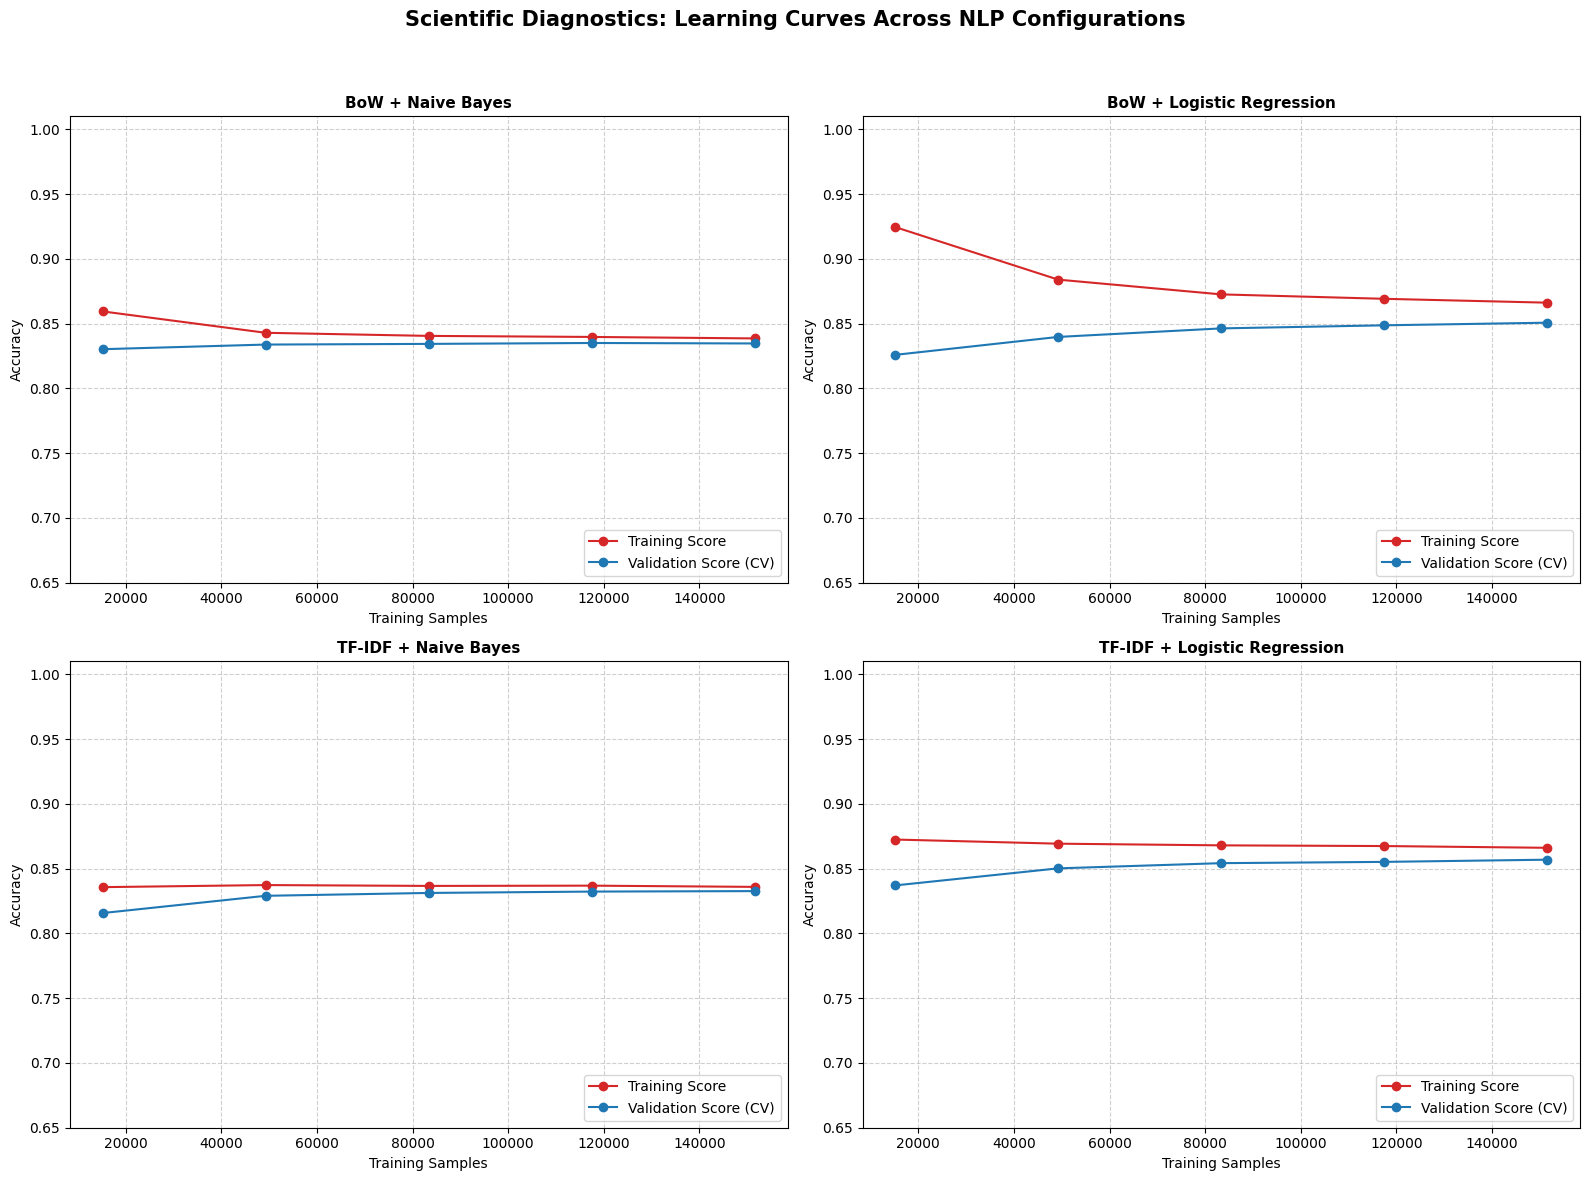

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_custom_learning_curve(model, X_data, y_data, title, ax):
    print(f"Computing Learning Curve for {title}...")
    
    # Evaluate the model at 5 different training sizes using 3-fold cross-validation
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_data, y_data, 
        train_sizes=np.linspace(0.1, 1.0, 5), 
        cv=3, 
        scoring='accuracy', 
        n_jobs=-1, 
        random_state=42
    )
    
    # Calculate means
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    # Plot curves
    ax.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Training Score")
    ax.plot(train_sizes, test_mean, 'o-', color="#1f77b4", label="Validation Score (CV)")
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Training Samples")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.65, 1.01) # Focused scale for better visual analysis
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc="lower right")

# Set up a 2x2 grid for the 4 text configurations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Row 1: Bag of Words (BoW)
plot_custom_learning_curve(nb_bow, X_train_bow, y_train, "BoW + Naive Bayes", axes[0, 0])
plot_custom_learning_curve(lr_bow, X_train_bow, y_train, "BoW + Logistic Regression", axes[0, 1])

# Row 2: TF-IDF
plot_custom_learning_curve(nb_tfidf, X_train_tfidf, y_train, "TF-IDF + Naive Bayes", axes[1, 0])
plot_custom_learning_curve(lr_tfidf, X_train_tfidf, y_train, "TF-IDF + Logistic Regression", axes[1, 1])

plt.suptitle("Scientific Diagnostics: Learning Curves Across NLP Configurations", fontsize=15, y=0.98, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### **Comparison of predictive text models with the text vectorization methods**

We consolidate the evaluation metrics for our text classifiers into a single comparative dataframe. In addition to general we display the accuracy, precision and recall. All scores are programmatically formatted as percentages to facilitate a clean, visual comparison between the Bag of Words and TF-IDF pipelines across both Naive Bayes and Logistic Regression models

In [20]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results = [
    {
        "Vectorization": "Bag of Words (BoW)", "Model": "Naive Bayes", 
        "Accuracy": accuracy_score(y_test, preds_nb_bow), 
        "Precision": precision_score(y_test, preds_nb_bow),
        "Recall": recall_score(y_test, preds_nb_bow),
        "F1-Score": f1_score(y_test, preds_nb_bow)
    },
    {
        "Vectorization": "Bag of Words (BoW)", "Model": "Logistic Regression", 
        "Accuracy": accuracy_score(y_test, preds_lr_bow), 
        "Precision": precision_score(y_test, preds_lr_bow),
        "Recall": recall_score(y_test, preds_lr_bow),
        "F1-Score": f1_score(y_test, preds_lr_bow)
    },
    {
        "Vectorization": "TF-IDF", "Model": "Naive Bayes", 
        "Accuracy": accuracy_score(y_test, preds_nb_tfidf), 
        "Precision": precision_score(y_test, preds_nb_tfidf),
        "Recall": recall_score(y_test, preds_nb_tfidf),
        "F1-Score": f1_score(y_test, preds_nb_tfidf)
    },
    {
        "Vectorization": "TF-IDF", "Model": "Logistic Regression", 
        "Accuracy": accuracy_score(y_test, preds_lr_tfidf), 
        "Precision": precision_score(y_test, preds_lr_tfidf),
        "Recall": recall_score(y_test, preds_lr_tfidf),
        "F1-Score": f1_score(y_test, preds_lr_tfidf)
    },
]

df_results = pd.DataFrame(results)

print("="*85)
print("🏆                     MODEL COMPARISON REPORT")
print("="*85)
print(df_results.to_string(index=False, formatters={
    'Accuracy': '{:,.2%}'.format,
    'Precision': '{:,.2%}'.format,
    'Recall': '{:,.2%}'.format,
    'F1-Score': '{:,.2%}'.format
}))
print("="*85)

🏆                     MODEL COMPARISON REPORT
     Vectorization               Model Accuracy Precision Recall F1-Score
Bag of Words (BoW)         Naive Bayes   83.49%    89.31% 88.55%   88.93%
Bag of Words (BoW) Logistic Regression   85.33%    87.00% 94.54%   90.61%
            TF-IDF         Naive Bayes   83.43%    83.07% 97.81%   89.84%
            TF-IDF Logistic Regression   85.76%    87.59% 94.36%   90.85%


### **Confussion Matrix for text predictive models**

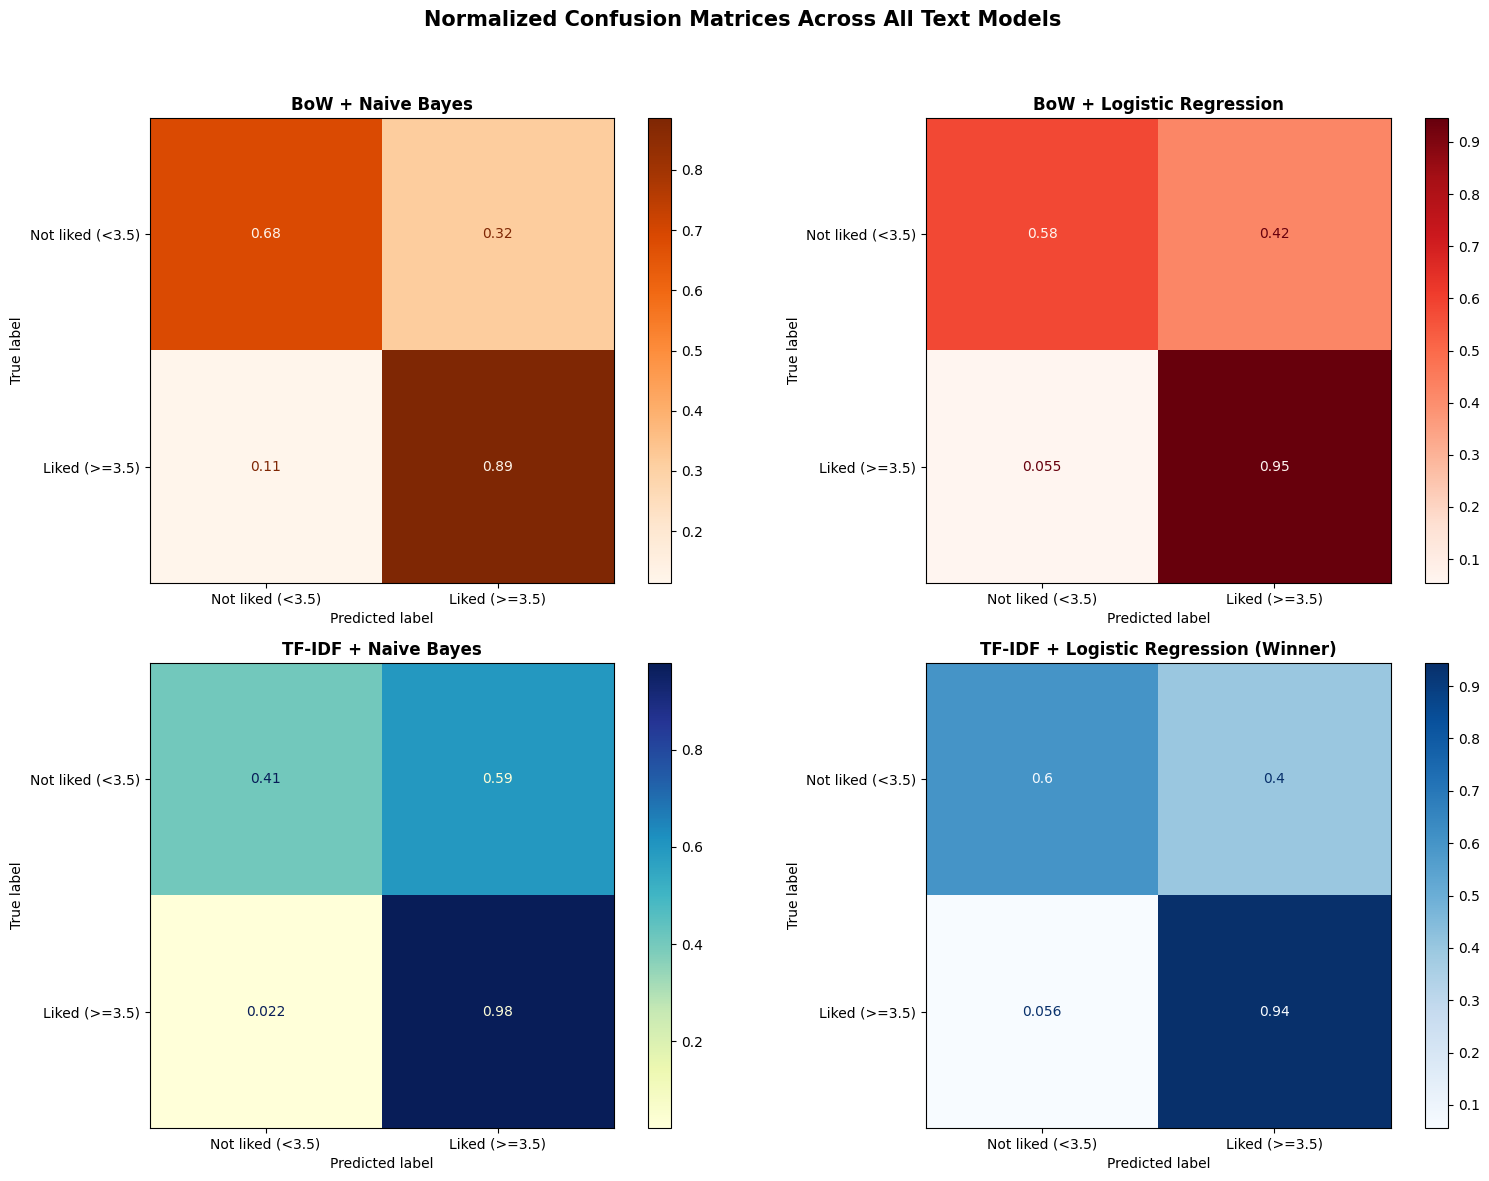

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Set up a 2x2 grid to display all 4 text-based models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- ROW 1: BAG OF WORDS (BoW) ---
# axes[0, 0]: BoW + Naive Bayes
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_nb_bow, 
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"], 
    ax=axes[0, 0], cmap='Oranges', normalize='true'
)
axes[0, 0].set_title("BoW + Naive Bayes", fontsize=12, fontweight='bold')

# axes[0, 1]: BoW + Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_lr_bow, 
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"], 
    ax=axes[0, 1], cmap='Reds', normalize='true'
)
axes[0, 1].set_title("BoW + Logistic Regression", fontsize=12, fontweight='bold')


# --- ROW 2: TF-IDF ---
# axes[1, 0]: TF-IDF + Naive Bayes
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_nb_tfidf, 
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"], 
    ax=axes[1, 0], cmap='YlGnBu', normalize='true'
)
axes[1, 0].set_title("TF-IDF + Naive Bayes", fontsize=12, fontweight='bold')

# axes[1, 1]: TF-IDF + Logistic Regression (Winner)
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_lr_tfidf, 
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"], 
    ax=axes[1, 1], cmap='Blues', normalize='true'
)
axes[1, 1].set_title("TF-IDF + Logistic Regression (Winner)", fontsize=12, fontweight='bold')


plt.suptitle("Normalized Confusion Matrices Across All Text Models", fontsize=15, y=0.98, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

---

# **Numeric predicting models**

In this section, we prepare our numerical dataset to train the Decision Tree, Random Forest, and Gradient Boosting classifiers. We extract the release_year from the date metadata and perform median imputation to clean any missing entries in our continuous features. The final matrix isolates four strategic indicators: movie duration, release year, and review interactions (likes/dislikes). This numerical subset is mapped against our binary satisfaction target (is_liked) to evaluate predictive performance outside of the textual domain.

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

print("Preparing features")

# 1. Extract the current year of realease
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
# Fill empty values
df['release_year'] = df['release_year'].fillna(df['release_year'].median())

# 2. Define the input columns  (X_num) and output ones (y)
numerical_features = ['runtime_in_minutes', 'likes', 'dislikes', 'release_year']
X_num = df[numerical_features].copy()

# Fill any empty value
X_num['runtime_in_minutes'] = X_num['runtime_in_minutes'].fillna(X_num['runtime_in_minutes'].median())

# 3. We reuse the target defined in first step
y_num = df['is_liked']

print(f"Numeric variables ready to train: {numerical_features}")

Preparing features
Numeric variables ready to train: ['runtime_in_minutes', 'likes', 'dislikes', 'release_year']


C:\Users\ivang\AppData\Local\Temp\ipykernel_18152\2695028310.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_num['runtime_in_minutes'] = X_num['runtime_in_minutes'].fillna(X_num['runtime_in_minutes'].median())


### **Numeric Model training**

We separate the tests and training set for the numeric data

In [9]:
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    X_num, y_num, test_size=0.2, random_state=42, stratify=y_num
)

print(f"Training numeric set: {X_train_num.shape[0]}")
print(f"Testing numeric set: {X_test_num.shape[0]} ")


Training numeric set: 20000
Testing numeric set: 5000 


We train three supervised tree-based algorithms on our numerical features: Decision Tree, Random Forest, and Gradient Boosting. Hyper-parameters such as max_depth and n_estimators are explicitly defined to control model complexity and avoid over-fitting. After fitting the data, each classifier predicts user satisfaction (is_liked) on the test set, allowing us to compare a single rule-based model against parallel and sequential ensemble methods.

In [10]:
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_num, y_train_num)
preds_dt = dt_model.predict(X_test_num)

print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_num, y_train_num)
preds_rf = rf_model.predict(X_test_num)

print("Training Gradient Boosting (Boosting)...")
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_num, y_train_num)
preds_gb = gb_model.predict(X_test_num)

print("All models trained succesfully")

Training Decision Tree...
Training Random Forest...
Training Gradient Boosting (Boosting)...
All models trained succesfully


### **Learning curve for numerical models**

This section generates a $1 \times 3$ grid comparing the learning curves of our tree-based tabular models: Decision Tree, Random Forest, and Gradient Boosting

Computing Accuracy Learning Curve for Decision Tree (Visibility)...
Computing Accuracy Learning Curve for Random Forest (Visibility)...
Computing Accuracy Learning Curve for Gradient Boosting (Visibility)...


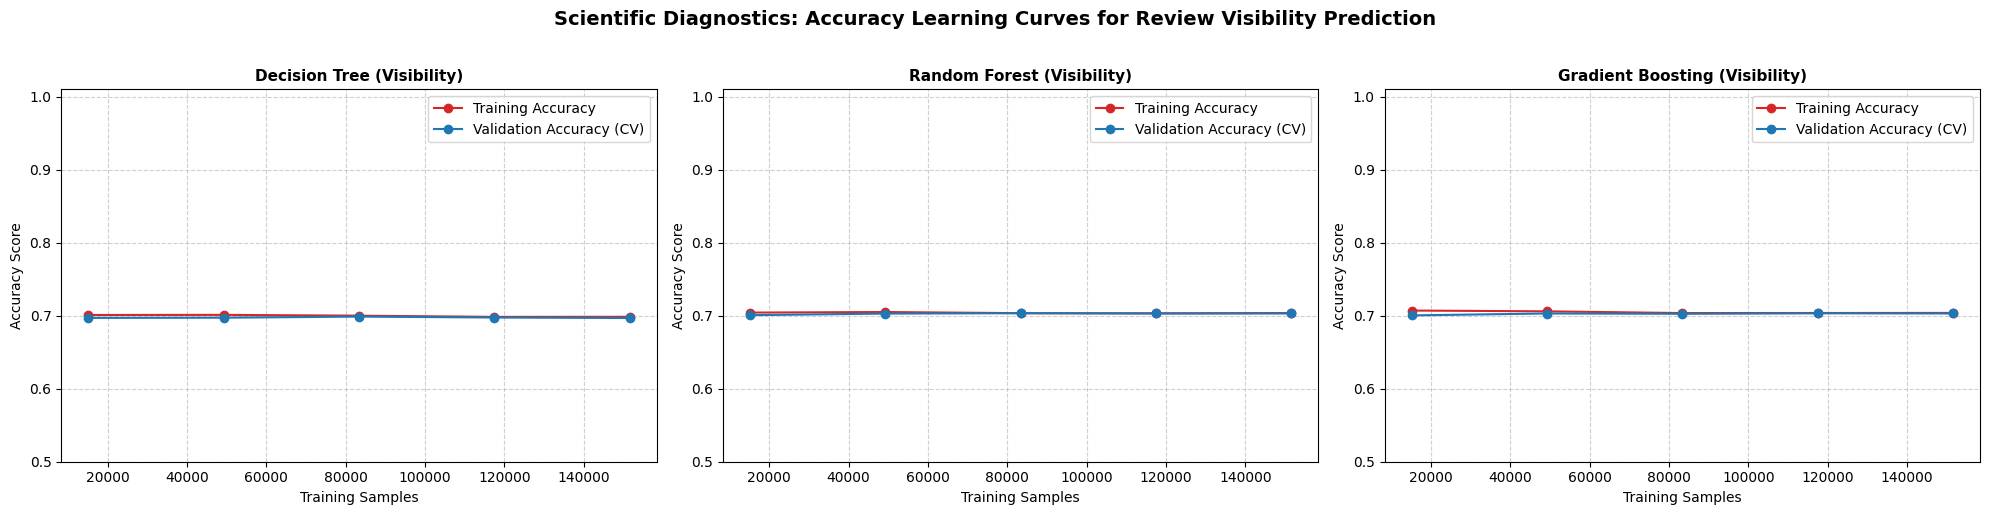

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_custom_learning_curve(model, X_data, y_data, title, ax):
    print(f"Computing Learning Curve for {title}...")
    
    # Evaluate the model at 5 different training sizes using 3-fold cross-validation
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_data, y_data, 
        train_sizes=np.linspace(0.1, 1.0, 5), 
        cv=3, 
        scoring='accuracy', 
        n_jobs=-1, 
        random_state=42
    )
    
    # Calculate means
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    # Plot curves
    ax.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Training Score")
    ax.plot(train_sizes, test_mean, 'o-', color="#1f77b4", label="Validation Score (CV)")
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Training Samples")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.65, 1.01) # Focused scale matching the text models for fair comparison
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc="best")

# Set up a 1x3 grid for the 3 numerical models
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plotting each tree-based model
plot_custom_learning_curve(dt_model, X_train_num, y_train_num, "Decision Tree (Numerical)", axes[0])
plot_custom_learning_curve(rf_model, X_train_num, y_train_num, "Random Forest (Numerical)", axes[1])
plot_custom_learning_curve(gb_model, X_train_num, y_train_num, "Gradient Boosting (Numerical)", axes[2])

plt.suptitle("Scientific Diagnostics: Learning Curves Across Tabular Configurations", fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

### **Comparison of predictive numerical models**

This block compiles the final performance report for our tabular pipeline, incorporating Precision and Recall metrics alongside Accuracy and F1-Score. 

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

num_results = [
    {
        "Model (Numerical Data)": "Decision Tree", 
        "Accuracy": accuracy_score(y_test_num, preds_dt), 
        "Precision": precision_score(y_test_num, preds_dt),
        "Recall": recall_score(y_test_num, preds_dt),
        "F1-Score": f1_score(y_test_num, preds_dt)
    },
    {
        "Model (Numerical Data)": "Random Forest", 
        "Accuracy": accuracy_score(y_test_num, preds_rf), 
        "Precision": precision_score(y_test_num, preds_rf),
        "Recall": recall_score(y_test_num, preds_rf),
        "F1-Score": f1_score(y_test_num, preds_rf)
    },
    {
        "Model (Numerical Data)": "Gradient Boosting (Boosting)", 
        "Accuracy": accuracy_score(y_test_num, preds_gb), 
        "Precision": precision_score(y_test_num, preds_gb),
        "Recall": recall_score(y_test_num, preds_gb),
        "F1-Score": f1_score(y_test_num, preds_gb)
    },
]

df_num_results = pd.DataFrame(num_results)

print("="*85)
print("🏆                  NUMERICAL MODELS COMPARISON REPORT (STAGE 5)")
print("="*85)
print(df_num_results.to_string(index=False, formatters={
    'Accuracy': '{:,.2%}'.format,
    'Precision': '{:,.2%}'.format,
    'Recall': '{:,.2%}'.format,
    'F1-Score': '{:,.2%}'.format
}))
print("="*85)

🏆                  NUMERICAL MODELS COMPARISON REPORT (STAGE 5)
      Model (Numerical Data) Accuracy Precision Recall F1-Score
               Decision Tree   77.30%    78.58% 95.98%   86.41%
               Random Forest   77.64%    78.42% 96.94%   86.70%
Gradient Boosting (Boosting)   77.74%    78.59% 96.76%   86.73%


### **Confussion Matrix for numerical predictive models**

This section generates a $1 \times 3$ grid of normalized confusion matrices to visually inspect the error distribution across our tabular architectures

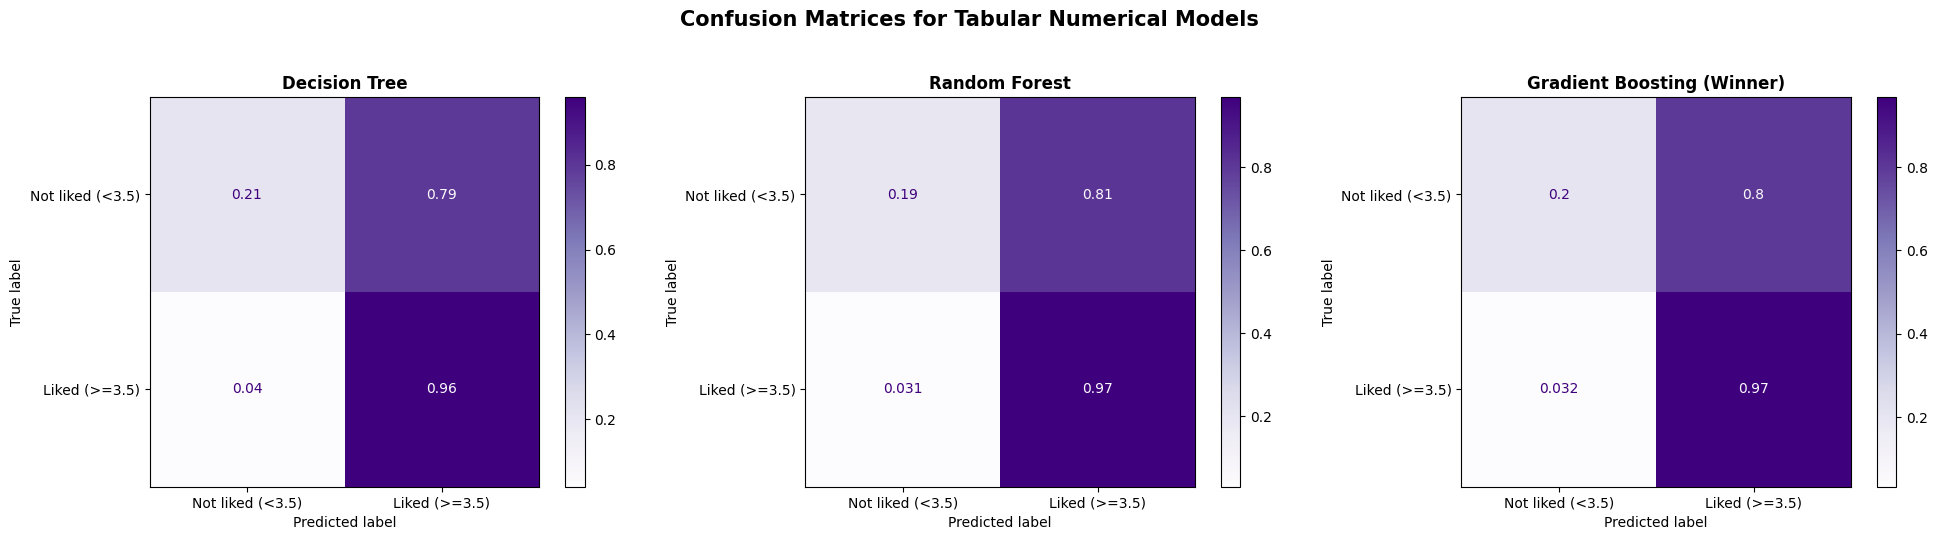

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Set up a 1x3 grid for the 3 numerical models
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Decision Tree Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_num, preds_dt, 
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"], 
    ax=axes[0], cmap='Purples', normalize='true'
)
axes[0].set_title("Decision Tree", fontsize=12, fontweight='bold')

# 2. Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_num, preds_rf, 
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"], 
    ax=axes[1], cmap='Purples', normalize='true'
)
axes[1].set_title("Random Forest", fontsize=12, fontweight='bold')

# 3. Gradient Boosting Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_num, preds_gb, 
    display_labels=["Not liked (<3.5)", "Liked (>=3.5)"], 
    ax=axes[2], cmap='Purples', normalize='true'
)
axes[2].set_title("Gradient Boosting (Winner)", fontsize=12, fontweight='bold')

plt.suptitle("Confusion Matrices for Tabular Numerical Models", fontsize=15, y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

### **Decission process for numerical training models**

We extract and visualize the internal decision-making process of our top-performing tabular algorithm through its Feature Importance attributes. By computing how much each split on a specific variable reduces the overall impurity (GINI or Mean Squared Error) across all 100 sequential trees, the Gradient Boosting model ranks our numerical features by their actual predictive power. This visualization serves as an interpretability layer, allowing us to scientifically verify whether the model relies on community validation metrics (likes/dislikes) or metadata attributes (runtime/release_year) to determine user satisfaction.

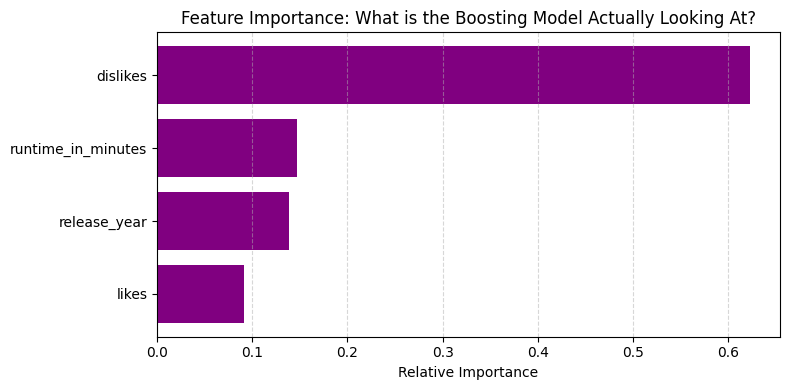

In [14]:
importances = gb_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': numerical_features, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='purple')
plt.xlabel('Relative Importance')
plt.title('Feature Importance: What is the Boosting Model Actually Looking At?')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()